In [7]:
# =============================================================================
# CELL 1 — GLOBAL CONFIGURATION
# =============================================================================
from pathlib import Path
import os
import re
import json
import itertools
import traceback
import warnings
import subprocess
import sys
from datetime import datetime

import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# 1) Path to the final Quad notebook
# -----------------------------------------------------------------------------
# Put this batch notebook next to Quad.ipynb, or set the full path here.
QUAD_NOTEBOOK_PATH = Path("Quad.ipynb")
AUTO_FIND_QUAD_NOTEBOOK = True

# -----------------------------------------------------------------------------
# 2) Input base datasets
# -----------------------------------------------------------------------------
# Recommended: explicitly list the 5 base datasets here.
RAW_DATASET_FILES = [
    # EDIT THESE 5 PATHS:
    # "output/single_datasets_report_only/Pre_M1.csv",
    # "output/single_datasets_report_only/Post1_M1.csv",
    # "output/single_datasets_report_only/Post2_M1.csv",
    # "output/single_datasets_report_only/ADC_M1.csv",
    # "output/single_datasets_report_only/T2_M1.csv",
]

# If RAW_DATASET_FILES is empty, auto-discover CSVs from this folder.
AUTO_DISCOVER_DATASETS = True
SOURCE_DATASET_DIR = Path("../Dataset/Breast-Data/Mask1")
DATASET_GLOB_PATTERN = "*.csv"

# Five datasets produce C(5, 4) = 5 quad combinations.
REQUIRE_EXACTLY_FIVE_DATASETS = True

# -----------------------------------------------------------------------------
# 3) Column names and alignment policy
# -----------------------------------------------------------------------------
LABEL_COL = "Label"
GROUP_COL = "PatientID"

ROI_CANDIDATE_COLUMNS = [
    "INFO_NameOfRoi",
    "NameOfRoi",
    "ROI",
    "ROI_Name",
    "LesionID",
    "Lesion_ID",
]

# The first key set that exists and is unique in all four datasets is used.
MERGE_KEY_PRIORITY = [
    ["INFO_NameOfRoi"],
    ["PatientID", "INFO_NameOfRoi"],
    ["LesionID"],
    ["Lesion_ID"],
    ["ROI_Name"],
]

# Row-order fallback is used only when all four row counts and PatientID orders match.
ALLOW_ROW_ORDER_FALLBACK = True
MERGE_HOW = "inner"

# -----------------------------------------------------------------------------
# 4) Output locations
# -----------------------------------------------------------------------------
QUAD_DATASET_DIR = Path("output/all_5_quad_concat_datasets")
BATCH_ROOT = Path("nested_cv_outputs_all_quad_concat_batch_smote_compare")
BATCH_RUN_ROOT = Path("batch_all_5_quad_runner_artifacts_smote_compare")

EXECUTED_NOTEBOOK_DIR = BATCH_RUN_ROOT / "executed_quad_notebooks"
MISMATCH_REPORT_DIR = BATCH_RUN_ROOT / "label_group_mismatch_reports"
SUMMARY_DIR = BATCH_RUN_ROOT / "summary_tables"

for p in [QUAD_DATASET_DIR, BATCH_ROOT, BATCH_RUN_ROOT, EXECUTED_NOTEBOOK_DIR, MISMATCH_REPORT_DIR, SUMMARY_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# 5) Notebook execution options
# -----------------------------------------------------------------------------
EXECUTE_QUAD_NOTEBOOKS = True
SKIP_EXISTING_SUCCESSFUL_RUNS = False
OVERWRITE_FS_RUNS = True
COMPARE_SMOTE_OPTIONS = True
RUN_SMOTE_ABLATION = False
RUN_SMOTE_VS_BASELINE_COMPARISON = False
KERNEL_NAME = "python3"
NOTEBOOK_TIMEOUT_SECONDS = None

ADD_PARAMETERS_TAG_TO_QUAD = True
PATCH_FINAL_ZIP_OUTPUT_IN_PLACE = True

print("Configuration loaded.")
print(f"QUAD_DATASET_DIR: {QUAD_DATASET_DIR.resolve()}")
print(f"BATCH_ROOT:         {BATCH_ROOT.resolve()}")
print(f"SUMMARY_DIR:        {SUMMARY_DIR.resolve()}")

Configuration loaded.
QUAD_DATASET_DIR: /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Quad/output/all_5_quad_concat_datasets
BATCH_ROOT:         /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Quad/nested_cv_outputs_all_quad_concat_batch_smote_compare
SUMMARY_DIR:        /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Quad/batch_all_5_quad_runner_artifacts_smote_compare/summary_tables


In [8]:
# =============================================================================
# CELL 2 — ONE-TIME DEPENDENCY CHECK
# =============================================================================

def ensure_import(import_name, pip_name=None):
    import importlib.util
    if importlib.util.find_spec(import_name) is None:
        pip_name = pip_name or import_name
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
    else:
        print(f"OK: {import_name}")

ensure_import("nbformat", "nbformat")
ensure_import("papermill", "papermill")
ensure_import("statsmodels", "statsmodels")
ensure_import("imblearn", "imbalanced-learn")

import nbformat
import papermill as pm

print("Dependency check completed.")

OK: nbformat
OK: papermill
OK: statsmodels
OK: imblearn
Dependency check completed.


In [9]:
# =============================================================================
# CELL 3 — FILE DISCOVERY AND VALIDATION
# =============================================================================

def find_quad_notebook(path: Path) -> Path:
    if path.exists():
        return path.resolve()

    if not AUTO_FIND_QUAD_NOTEBOOK:
        raise FileNotFoundError(f"Quad notebook not found: {path}")

    candidates = []
    for root in [Path.cwd(), Path("/kaggle/input"), Path("/mnt/data")]:
        if root.exists():
            try:
                candidates.extend(root.rglob(QUAD_NOTEBOOK_PATH.name))
            except Exception:
                pass

    candidates = sorted(set(candidates))
    if len(candidates) == 0:
        raise FileNotFoundError(
            f"Could not find {QUAD_NOTEBOOK_PATH.name}. Put it next to this notebook or set QUAD_NOTEBOOK_PATH."
        )

    print(f"Found {QUAD_NOTEBOOK_PATH.name} candidates:")
    for c in candidates:
        print("  -", c)

    return candidates[0].resolve()


def discover_dataset_files():
    if len(RAW_DATASET_FILES) > 0:
        files = [Path(x) for x in RAW_DATASET_FILES]
    else:
        if not AUTO_DISCOVER_DATASETS:
            raise ValueError("RAW_DATASET_FILES is empty and AUTO_DISCOVER_DATASETS=False.")
        if not SOURCE_DATASET_DIR.exists():
            raise FileNotFoundError(
                f"SOURCE_DATASET_DIR does not exist: {SOURCE_DATASET_DIR}\n"
                "Either create this folder or fill RAW_DATASET_FILES manually."
            )
        files = sorted(SOURCE_DATASET_DIR.glob(DATASET_GLOB_PATTERN))

    filtered = []
    excluded_terms = ["pairwise", "quad", "quad", "summary", "comparison", "random_label"]
    for p in files:
        if any(term in p.stem.lower() for term in excluded_terms):
            continue
        filtered.append(p)

    files = [p.resolve() for p in filtered]
    missing = [str(p) for p in files if not p.exists()]
    if missing:
        raise FileNotFoundError("These dataset files were not found:\n" + "\n".join(missing))

    if REQUIRE_EXACTLY_FIVE_DATASETS and len(files) != 5:
        raise ValueError(
            f"Expected exactly 5 base datasets to create 5 quads, but found {len(files)}.\n"
            "Files found:\n" + "\n".join(str(p) for p in files) + "\n\n"
            "Fix RAW_DATASET_FILES or SOURCE_DATASET_DIR."
        )

    if len(files) < 4:
        raise ValueError(f"At least 4 base datasets are required; found {len(files)}.")

    return files


QUAD_NOTEBOOK_PATH = find_quad_notebook(QUAD_NOTEBOOK_PATH)
DATASET_FILES = discover_dataset_files()

print("Quad notebook:")
print(" ", QUAD_NOTEBOOK_PATH)

print("\nBase datasets:")
for i, f in enumerate(DATASET_FILES, start=1):
    print(f"{i}. {f}")

expected_quads = len(list(itertools.combinations(DATASET_FILES, 4)))
print(f"\nNumber of concat quads to create: {expected_quads}")

Quad notebook:
  /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Quad/Quad.ipynb

Base datasets:
1. /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Dataset/Breast-Data/Mask1/ADC_M1.csv
2. /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Dataset/Breast-Data/Mask1/Post1_M1.csv
3. /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Dataset/Breast-Data/Mask1/Post2_M1.csv
4. /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Dataset/Breast-Data/Mask1/Pre_M1.csv
5. /Users/mahla/MyDrive/Res

In [10]:
# =============================================================================
# CELL 4 — DATASET READING, TAGGING, AND QUAD CONCAT FUNCTIONS
# =============================================================================

def clean_tag_from_path(path):
    """Create a compact dataset tag from filename."""
    stem = Path(path).stem
    suffixes = [
        "_Cleaned", "_cleaned", "_M1_quad", "_quad",
        "_M1_pairwise", "_pairwise", "_M1"
    ]
    changed = True
    while changed:
        changed = False
        for suffix in suffixes:
            if stem.endswith(suffix):
                stem = stem[:-len(suffix)]
                changed = True
    return re.sub(r"[^A-Za-z0-9]+", "_", stem).strip("_")


def read_csv_flexible(path):
    """Read comma-, semicolon-, tab-, or whitespace-separated CSV robustly."""
    attempts = [
        dict(sep=None, engine="python"),
        dict(sep=","),
        dict(sep=";"),
        dict(sep="\t"),
        dict(sep=r"\s+", engine="python"),
    ]
    last_error = None
    for kwargs in attempts:
        try:
            df = pd.read_csv(path, **kwargs)
            if df.shape[1] > 1:
                return df
        except Exception as exc:
            last_error = exc
    raise RuntimeError(f"Could not read CSV correctly: {path}\nLast error: {last_error}")


def normalize_column_lookup(df):
    return {str(c).strip().lower(): c for c in df.columns}


def resolve_column(df, preferred, candidates=None, required=True, role_name="column"):
    lookup = normalize_column_lookup(df)
    for term in [preferred] + list(candidates or []):
        if term is not None and str(term).strip().lower() in lookup:
            return lookup[str(term).strip().lower()]
    if required:
        raise ValueError(
            f"Could not find required {role_name}. Preferred={preferred}, candidates={candidates}. "
            f"Available columns include: {list(df.columns[:20])}"
        )
    return None


def standardize_label_column(df):
    detected = resolve_column(
        df, LABEL_COL,
        candidates=["label", "Label", "Class", "class", "target", "Target", "diagnosis"],
        required=True, role_name="label column"
    )
    return df.rename(columns={detected: LABEL_COL}) if detected != LABEL_COL else df.copy()


def find_first_existing_column(df, candidates):
    lookup = normalize_column_lookup(df)
    for candidate in candidates:
        key = str(candidate).strip().lower()
        if key in lookup:
            return lookup[key]
    return None


def derive_patient_id(df):
    df = df.copy()
    if GROUP_COL in df.columns and df[GROUP_COL].notna().any():
        source = df[GROUP_COL].astype(str)
    else:
        roi_col = find_first_existing_column(df, ROI_CANDIDATE_COLUMNS)
        patient_col = find_first_existing_column(
            df, ["INFO_PatientName", "PatientName", "patient_name", "SubjectID", "CaseID", "ID"]
        )
        if roi_col is not None:
            source = df[roi_col].astype(str)
        elif patient_col is not None:
            source = df[patient_col].astype(str)
        else:
            raise ValueError(
                "Could not derive PatientID. Provide PatientID, INFO_NameOfRoi, or INFO_PatientName."
            )

    extracted = source.str.extract(r"(P\d+)", expand=False)
    fallback = source.str.replace(r"^[A-Za-z0-9]+_D_", "", regex=True)
    fallback = fallback.str.replace(r"[^A-Za-z0-9]+", "_", regex=True).str.strip("_")
    df[GROUP_COL] = extracted.fillna(fallback).astype(str)
    return df


def preprocess_base_dataset(path):
    df = read_csv_flexible(path).copy()
    empty_cols = df.columns[df.isna().all()].tolist()
    if empty_cols:
        df = df.drop(columns=empty_cols)
    unnamed_cols = [c for c in df.columns if str(c).startswith("Unnamed:")]
    if unnamed_cols:
        df = df.drop(columns=unnamed_cols)
    df = standardize_label_column(df)
    df = derive_patient_id(df)
    return df


def choose_merge_keys_many(datasets):
    """Choose one safe merge key that is present and unique in all four datasets."""
    candidate_sets = list(MERGE_KEY_PRIORITY)
    for roi_col in ROI_CANDIDATE_COLUMNS:
        candidate_sets.append([roi_col])
        candidate_sets.append([GROUP_COL, roi_col])
    candidate_sets.append([GROUP_COL])

    seen = set()
    for keys in candidate_sets:
        keys = [k for k in keys if k is not None]
        key_tuple = tuple(keys)
        if key_tuple in seen:
            continue
        seen.add(key_tuple)
        if all(all(k in df.columns for k in keys) for df in datasets):
            if all(int(df.duplicated(subset=keys).sum()) == 0 for df in datasets):
                return keys, "unique_key"

    if ALLOW_ROW_ORDER_FALLBACK:
        same_length = len({len(df) for df in datasets}) == 1
        if same_length:
            base_order = datasets[0][GROUP_COL].astype(str).reset_index(drop=True)
            same_order = all(
                base_order.equals(df[GROUP_COL].astype(str).reset_index(drop=True))
                for df in datasets[1:]
            )
            if same_order:
                for df in datasets:
                    df["__row_index_quad_key__"] = np.arange(len(df))
                return ["__row_index_quad_key__"], "row_order_fallback"

    raise ValueError(
        "No safe common unique merge key was found across all four datasets. "
        "Use a unique ROI/Lesion column or verify identical PatientID row order."
    )



def prepare_dataset_for_quad_merge(df, tag, keys):
    """Keep merge keys shared; tag all other metadata and feature columns."""
    df = df.copy()
    metadata_candidates = [GROUP_COL, LABEL_COL, "INFO_PatientName"] + ROI_CANDIDATE_COLUMNS
    meta_cols = list(keys)
    for col in metadata_candidates:
        if col in df.columns and col not in meta_cols:
            meta_cols.append(col)

    feature_cols = [c for c in df.columns if c not in meta_cols]
    rename_map = {}
    for col in meta_cols:
        if col not in keys:
            rename_map[col] = f"{col}__{tag}"
    for col in feature_cols:
        rename_map[col] = f"{tag}__{col}"

    prepared = df[meta_cols + feature_cols].rename(columns=rename_map)
    tagged_features = [rename_map[c] for c in feature_cols]
    return prepared, tagged_features


def tagged_metadata_column(base_col, tag, keys, merged):
    if base_col in keys and base_col in merged.columns:
        return base_col
    candidate = f"{base_col}__{tag}"
    return candidate if candidate in merged.columns else None


def mismatch_mask_against_first(merged, columns):
    reference = merged[columns[0]].astype(str).str.strip()
    mask = pd.Series(False, index=merged.index)
    for col in columns[1:]:
        mask |= reference.ne(merged[col].astype(str).str.strip())
    return mask


def build_concat_quad_dataset(path_a, path_b, path_c, path_d):
    paths = [Path(path_a), Path(path_b), Path(path_c), Path(path_d)]
    tags = [clean_tag_from_path(path) for path in paths]
    quad_tag = "_".join(tags)
    output_path = QUAD_DATASET_DIR / f"{quad_tag}_M1_quad.csv"

    datasets = [preprocess_base_dataset(path) for path in paths]
    keyed_datasets = [df.copy() for df in datasets]
    keys, key_mode = choose_merge_keys_many(keyed_datasets)

    prepared = []
    feature_lists = []
    for df, tag in zip(keyed_datasets, tags):
        pre, features = prepare_dataset_for_quad_merge(df, tag, keys)
        prepared.append(pre)
        feature_lists.append(features)

    merged = prepared[0]
    for next_df in prepared[1:]:
        merged = merged.merge(next_df, on=keys, how=MERGE_HOW, validate="one_to_one")

    if len(merged) == 0:
        raise ValueError(
            f"{quad_tag}: merge produced 0 rows. Check keys={keys} and MERGE_HOW={MERGE_HOW}."
        )

    label_cols = [tagged_metadata_column(LABEL_COL, tag, keys, merged) for tag in tags]
    if any(col is None for col in label_cols):
        raise ValueError(f"{quad_tag}: could not identify all four label columns after merge.")

    label_mismatch = mismatch_mask_against_first(merged, label_cols)
    if label_mismatch.any():
        report_path = MISMATCH_REPORT_DIR / f"{quad_tag}_label_mismatches.csv"
        merged.loc[label_mismatch, keys + label_cols].to_csv(report_path, index=False)
        raise ValueError(
            f"Label mismatch detected for quad {quad_tag}: {int(label_mismatch.sum())} rows. "
            f"Report saved to: {report_path}"
        )

    group_cols = [tagged_metadata_column(GROUP_COL, tag, keys, merged) for tag in tags]
    existing_group_cols = [col for col in group_cols if col is not None]
    if len(existing_group_cols) >= 2:
        group_mismatch = mismatch_mask_against_first(merged, existing_group_cols)
        if group_mismatch.any():
            report_path = MISMATCH_REPORT_DIR / f"{quad_tag}_group_mismatches.csv"
            merged.loc[group_mismatch, keys + existing_group_cols].to_csv(report_path, index=False)
            raise ValueError(
                f"PatientID mismatch detected for quad {quad_tag}: {int(group_mismatch.sum())} rows. "
                f"Report saved to: {report_path}"
            )

    final_df = pd.DataFrame(index=merged.index)
    if existing_group_cols:
        final_df[GROUP_COL] = merged[existing_group_cols[0]].astype(str)
    else:
        final_df[GROUP_COL] = merged[keys[0]].astype(str)

    # Preserve one representative ROI and patient-name metadata column.
    roi_source = None
    for roi_candidate in ROI_CANDIDATE_COLUMNS:
        if roi_candidate in keys and roi_candidate in merged.columns:
            roi_source = roi_candidate
            break
        candidate = tagged_metadata_column(roi_candidate, tags[0], keys, merged)
        if candidate is not None:
            roi_source = candidate
            break
    if roi_source is not None:
        final_df["INFO_NameOfRoi"] = merged[roi_source].astype(str)

    patient_name_source = tagged_metadata_column("INFO_PatientName", tags[0], keys, merged)
    if patient_name_source is not None:
        final_df["INFO_PatientName"] = merged[patient_name_source].astype(str)

    for feature_list in feature_lists:
        for col in feature_list:
            if col in merged.columns:
                final_df[col] = merged[col]

    final_df[LABEL_COL] = pd.to_numeric(merged[label_cols[0]], errors="raise").astype(int)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    final_df.to_csv(output_path, index=False)

    label_counts = final_df[LABEL_COL].value_counts().sort_index().to_dict()
    numeric_feature_count = len([
        c for c in final_df.select_dtypes(include=[np.number]).columns if c != LABEL_COL
    ])

    meta = {
        "Quad_Tag": quad_tag,
        "Dataset_A": tags[0],
        "Dataset_B": tags[1],
        "Dataset_C": tags[2],
        "Dataset_D": tags[3],
        "Dataset_A_Path": str(paths[0]),
        "Dataset_B_Path": str(paths[1]),
        "Dataset_C_Path": str(paths[2]),
        "Dataset_D_Path": str(paths[3]),
        "Quad_Input_File": str(output_path.resolve()),
        "Merge_Keys": ",".join(keys),
        "Merge_Key_Mode": key_mode,
        "Merge_How": MERGE_HOW,
        "Rows_A": int(len(datasets[0])),
        "Rows_B": int(len(datasets[1])),
        "Rows_C": int(len(datasets[2])),
        "Rows_D": int(len(datasets[3])),
        "Rows_After_Merge": int(len(final_df)),
        "N_Features_A": int(len(feature_lists[0])),
        "N_Features_B": int(len(feature_lists[1])),
        "N_Features_C": int(len(feature_lists[2])),
        "N_Features_D": int(len(feature_lists[3])),
        "N_Features_Total": int(numeric_feature_count),
        "Label_Counts": json.dumps({str(k): int(v) for k, v in label_counts.items()}, ensure_ascii=False),
        "Status": "dataset_created",
        "Error": "",
    }
    return output_path.resolve(), meta


In [11]:

# =============================================================================
# CELL 5 — CREATE ALL 5 CONCAT QUAD DATASETS
# =============================================================================

quad_dataset_rows = []
quad_dataset_paths = []

for path_a, path_b, path_c, path_d in itertools.combinations(DATASET_FILES, 4):
    paths = [path_a, path_b, path_c, path_d]
    tags = [clean_tag_from_path(path) for path in paths]
    quad_tag = "_".join(tags)
    try:
        out_path, meta = build_concat_quad_dataset(path_a, path_b, path_c, path_d)
        quad_dataset_paths.append(out_path)
        quad_dataset_rows.append(meta)
        print(
            f"✅ Created: {meta['Quad_Tag']} | rows={meta['Rows_After_Merge']} | "
            f"features={meta['N_Features_Total']} | keys={meta['Merge_Keys']}"
        )
    except Exception as exc:
        quad_dataset_rows.append({
            "Quad_Tag": quad_tag,
            "Dataset_A": tags[0],
            "Dataset_B": tags[1],
            "Dataset_C": tags[2],
            "Dataset_D": tags[3],
            "Dataset_A_Path": str(path_a),
            "Dataset_B_Path": str(path_b),
            "Dataset_C_Path": str(path_c),
            "Dataset_D_Path": str(path_d),
            "Quad_Input_File": "",
            "Merge_Keys": "",
            "Merge_Key_Mode": "",
            "Merge_How": MERGE_HOW,
            "Rows_A": np.nan,
            "Rows_B": np.nan,
            "Rows_C": np.nan,
            "Rows_D": np.nan,
            "Rows_After_Merge": np.nan,
            "N_Features_A": np.nan,
            "N_Features_B": np.nan,
            "N_Features_C": np.nan,
            "N_Features_D": np.nan,
            "N_Features_Total": np.nan,
            "Label_Counts": "",
            "Status": "dataset_creation_failed",
            "Error": str(exc),
        })
        print(f"❌ Failed to create quad dataset: {quad_tag}")
        print(str(exc))


df_quad_datasets = pd.DataFrame(quad_dataset_rows)
dataset_log_path = SUMMARY_DIR / "quad_concat_dataset_creation_log.csv"
df_quad_datasets.to_csv(dataset_log_path, index=False)

print("\nSaved dataset creation log:")
print(dataset_log_path)
display(df_quad_datasets)


✅ Created: ADC_Post1_Post2_Pre | rows=113 | features=580 | keys=INFO_NameOfRoi
✅ Created: ADC_Post1_Post2_T2 | rows=113 | features=580 | keys=INFO_NameOfRoi
✅ Created: ADC_Post1_Pre_T2 | rows=113 | features=580 | keys=INFO_NameOfRoi
✅ Created: ADC_Post2_Pre_T2 | rows=114 | features=580 | keys=INFO_NameOfRoi
✅ Created: Post1_Post2_Pre_T2 | rows=116 | features=580 | keys=INFO_NameOfRoi

Saved dataset creation log:
batch_all_5_quad_runner_artifacts_smote_compare/summary_tables/quad_concat_dataset_creation_log.csv


,Quad_Tag,Dataset_A,Dataset_B,Dataset_C,Dataset_D,Dataset_A_Path,Dataset_B_Path,Dataset_C_Path,Dataset_D_Path,Quad_Input_File,...,Rows_D,Rows_After_Merge,N_Features_A,N_Features_B,N_Features_C,N_Features_D,N_Features_Total,Label_Counts,Status,Error
0,ADC_Post1_Post2_Pre,ADC,Post1,Post2,Pre,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,...,117,113,145,145,145,145,580,"{""0"": 50, ""1"": 63}",dataset_created,
1,ADC_Post1_Post2_T2,ADC,Post1,Post2,T2,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,...,117,113,145,145,145,145,580,"{""0"": 50, ""1"": 63}",dataset_created,
2,ADC_Post1_Pre_T2,ADC,Post1,Pre,T2,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,...,117,113,145,145,145,145,580,"{""0"": 50, ""1"": 63}",dataset_created,
3,ADC_Post2_Pre_T2,ADC,Post2,Pre,T2,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,...,117,114,145,145,145,145,580,"{""0"": 50, ""1"": 64}",dataset_created,
4,Post1_Post2_Pre_T2,Post1,Post2,Pre,T2,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,...,117,116,145,145,145,145,580,"{""0"": 52, ""1"": 64}",dataset_created,


In [12]:
# =============================================================================
# CELL 6 — RUN THE SAME Quad.ipynb WITH PARAMETERS VIA PAPERMILL
# =============================================================================

def ensure_quad_accepts_papermill_parameters(nb_path):
    nb_path = Path(nb_path)
    notebook = nbformat.read(nb_path, as_version=4)
    if len(notebook.cells) == 0:
        raise ValueError("Quad.ipynb has no cells.")

    changed = False
    if ADD_PARAMETERS_TAG_TO_QUAD:
        tags = list(notebook.cells[0].metadata.get("tags", []))
        if "parameters" not in tags:
            tags.append("parameters")
            notebook.cells[0].metadata["tags"] = tags
            changed = True
            print("Added 'parameters' tag to cell 0 of Quad.ipynb.")

    if PATCH_FINAL_ZIP_OUTPUT_IN_PLACE:
        for cell in notebook.cells:
            if cell.cell_type != "code":
                continue
            src = cell.source
            if "output_zip_path = os.path.join(base_working_dir, ACTIVE_RUN_NAME)" in src:
                new_src = src.replace(
                    "staging_dir = os.path.join(base_working_dir, 'final_outputs')",
                    "staging_dir = os.path.join(CONFIG.get('DATASET_OUTPUT_ROOT', base_working_dir), '_final_outputs_staging')"
                ).replace(
                    "output_zip_path = os.path.join(base_working_dir, ACTIVE_RUN_NAME)",
                    "output_zip_path = os.path.join(CONFIG.get('DATASET_OUTPUT_ROOT', base_working_dir), ACTIVE_RUN_NAME)"
                )
                if new_src != src:
                    cell.source = new_src
                    changed = True
                    print("Patched final zip output path to be quad-specific.")

    if changed:
        try:
            nbformat.write(notebook, nb_path)
            print("Quad.ipynb updated in place for papermill parameters.")
            return nb_path
        except Exception as exc:
            fallback = BATCH_RUN_ROOT / "Quad_parameter_ready.ipynb"
            nbformat.write(notebook, fallback)
            print(f"Could not write to original Quad.ipynb: {exc}")
            print(f"Using reusable parameter-ready copy: {fallback}")
            return fallback.resolve()

    print("Quad.ipynb already parameter-ready.")
    return nb_path


def final_quad_summary_exists(quad_tag):
    return (
        BATCH_ROOT / quad_tag / "fs_method_comparison" / "_comparison_summary" /
        "publication_fs_comparison_best_per_method.csv"
    ).exists()


def build_quad_parameters(quad_input_file, quad_tag):
    quad_input_file = Path(quad_input_file).resolve()
    output_dir = Path("output/cleaned_quad_all_5_smote_compare") / quad_tag
    dataset_output_root = BATCH_ROOT / quad_tag
    cleaned_dataset_path = output_dir / f"{quad_input_file.stem}_Cleaned.csv"

    return {
        "INPUT_FILE": str(quad_input_file),
        "DATASET_TAG": str(quad_tag),
        "BATCH_ROOT": str(BATCH_ROOT),
        "OUTPUT_DIR": str(output_dir),
        "TARGET_COLUMN": str(LABEL_COL),
        "DATASET_OUTPUT_ROOT": str(dataset_output_root),
        "CLEANED_DATASET_PATH": str(cleaned_dataset_path),
        "OVERWRITE_FS_RUNS": bool(OVERWRITE_FS_RUNS),
        "COMPARE_SMOTE_OPTIONS": bool(COMPARE_SMOTE_OPTIONS),
        "TARGET_ABLATION": None,
        "RUN_SMOTE_ABLATION": bool(RUN_SMOTE_ABLATION),
        "RUN_SMOTE_VS_BASELINE_COMPARISON": bool(RUN_SMOTE_VS_BASELINE_COMPARISON),
        "IS_BATCH_RUN": True,
        "PAPERMILL_BATCH_RUN": True,
        "BATCH_MODE": True,
        "RUN_PUBLICATION_PLOTS": False,
    }


QUAD_EXEC_NOTEBOOK_PATH = ensure_quad_accepts_papermill_parameters(QUAD_NOTEBOOK_PATH)
run_rows = []

if EXECUTE_QUAD_NOTEBOOKS:
    for _, row in df_quad_datasets.iterrows():
        quad_tag = row["Quad_Tag"]
        if row["Status"] != "dataset_created":
            run_rows.append({
                "Quad_Tag": quad_tag,
                "Run_Status": "not_run_dataset_creation_failed",
                "Executed_Notebook": "",
                "Error": row.get("Error", ""),
                "Started_At": "",
                "Finished_At": "",
            })
            continue

        if SKIP_EXISTING_SUCCESSFUL_RUNS and final_quad_summary_exists(quad_tag):
            print(f"⏭️ Skipping existing successful run: {quad_tag}")
            run_rows.append({
                "Quad_Tag": quad_tag,
                "Run_Status": "skipped_existing",
                "Executed_Notebook": "",
                "Error": "",
                "Started_At": "",
                "Finished_At": "",
            })
            continue

        params = build_quad_parameters(str(Path(row["Quad_Input_File"]).resolve()), quad_tag)
        executed_path = EXECUTED_NOTEBOOK_DIR / f"{quad_tag}__Quad_executed.ipynb"
        started = datetime.now().isoformat(timespec="seconds")

        print("\n" + "=" * 100)
        print(f"RUNNING QUAD: {quad_tag}")
        print("Input:", str(Path(row["Quad_Input_File"]).resolve()))
        print("Output root:", params["DATASET_OUTPUT_ROOT"])
        print("=" * 100)

        try:
            pm.execute_notebook(
                input_path=str(QUAD_EXEC_NOTEBOOK_PATH),
                output_path=str(executed_path),
                parameters=params,
                kernel_name=KERNEL_NAME,
                cwd=str(Path.cwd()),
                progress_bar=True,
                log_output=False,
                request_save_on_cell_execute=True,
                execution_timeout=NOTEBOOK_TIMEOUT_SECONDS,
            )
            finished = datetime.now().isoformat(timespec="seconds")
            run_rows.append({
                "Quad_Tag": quad_tag,
                "Run_Status": "completed",
                "Executed_Notebook": str(executed_path),
                "Error": "",
                "Started_At": started,
                "Finished_At": finished,
            })
            print(f"✅ Completed: {quad_tag}")
        except Exception as exc:
            finished = datetime.now().isoformat(timespec="seconds")
            error_text = traceback.format_exc()
            fail_path = EXECUTED_NOTEBOOK_DIR / f"{quad_tag}__FAILED_error.txt"
            fail_path.write_text(error_text, encoding="utf-8")
            run_rows.append({
                "Quad_Tag": quad_tag,
                "Run_Status": "failed",
                "Executed_Notebook": str(executed_path) if executed_path.exists() else "",
                "Error": str(exc),
                "Started_At": started,
                "Finished_At": finished,
            })
            print(f"❌ Failed: {quad_tag}")
            print(str(exc))
else:
    print("EXECUTE_QUAD_NOTEBOOKS=False. Quad datasets were created but notebooks were not executed.")
    for _, row in df_quad_datasets.iterrows():
        run_rows.append({
            "Quad_Tag": row["Quad_Tag"],
            "Run_Status": "not_executed",
            "Executed_Notebook": "",
            "Error": "",
            "Started_At": "",
            "Finished_At": "",
        })


df_run_log = pd.DataFrame(run_rows)
run_log_path = SUMMARY_DIR / "all_5_quad_notebook_run_log.csv"
df_run_log.to_csv(run_log_path, index=False)
print("\nRun log saved:")
print(run_log_path)
display(df_run_log)

Quad.ipynb already parameter-ready.

RUNNING QUAD: ADC_Post1_Post2_Pre
Input: /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Quad/output/all_5_quad_concat_datasets/ADC_Post1_Post2_Pre_M1_quad.csv
Output root: nested_cv_outputs_all_quad_concat_batch_smote_compare/ADC_Post1_Post2_Pre


Executing:   0%|          | 0/86 [00:00<?, ?cell/s]

✅ Completed: ADC_Post1_Post2_Pre

RUNNING QUAD: ADC_Post1_Post2_T2
Input: /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Quad/output/all_5_quad_concat_datasets/ADC_Post1_Post2_T2_M1_quad.csv
Output root: nested_cv_outputs_all_quad_concat_batch_smote_compare/ADC_Post1_Post2_T2


Executing:   0%|          | 0/86 [00:00<?, ?cell/s]

✅ Completed: ADC_Post1_Post2_T2

RUNNING QUAD: ADC_Post1_Pre_T2
Input: /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Quad/output/all_5_quad_concat_datasets/ADC_Post1_Pre_T2_M1_quad.csv
Output root: nested_cv_outputs_all_quad_concat_batch_smote_compare/ADC_Post1_Pre_T2


...

Executing:   0%|          | 0/86 [00:00<?, ?cell/s]

✅ Completed: ADC_Post2_Pre_T2

RUNNING QUAD: Post1_Post2_Pre_T2
Input: /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Quad/output/all_5_quad_concat_datasets/Post1_Post2_Pre_T2_M1_quad.csv
Output root: nested_cv_outputs_all_quad_concat_batch_smote_compare/Post1_Post2_Pre_T2


Executing:   0%|          | 0/86 [00:00<?, ?cell/s]

✅ Completed: Post1_Post2_Pre_T2

Run log saved:
batch_all_5_quad_runner_artifacts_smote_compare/summary_tables/all_5_quad_notebook_run_log.csv


,Quad_Tag,Run_Status,Executed_Notebook,Error,Started_At,Finished_At
0,ADC_Post1_Post2_Pre,completed,batch_all_5_quad_runner_artifacts_smote_compar...,,2026-07-11T19:38:25,2026-07-11T19:48:02
1,ADC_Post1_Post2_T2,completed,batch_all_5_quad_runner_artifacts_smote_compar...,,2026-07-11T19:48:02,2026-07-11T19:57:28
2,ADC_Post1_Pre_T2,completed,batch_all_5_quad_runner_artifacts_smote_compar...,,2026-07-11T19:57:28,2026-07-11T20:07:14
3,ADC_Post2_Pre_T2,completed,batch_all_5_quad_runner_artifacts_smote_compar...,,2026-07-11T20:07:14,2026-07-11T20:17:34
4,Post1_Post2_Pre_T2,completed,batch_all_5_quad_runner_artifacts_smote_compar...,,2026-07-11T20:17:34,2026-07-11T20:27:15


In [13]:
# =============================================================================
# CELL 7 — COLLECT BEST RESULTS FROM EACH QUAD RUN
# =============================================================================

def read_best_result_for_quad(quad_tag):
    quad_root = BATCH_ROOT / quad_tag
    summary_root = quad_root / "fs_method_comparison" / "_comparison_summary"

    ranking_path = summary_root / "fs_method_composite_ranking.csv"
    publication_path = summary_root / "publication_fs_comparison_best_per_method.csv"
    best_per_method_path = summary_root / "fs_comparison_best_model_per_method.csv"
    all_models_path = summary_root / "fs_comparison_all_models.csv"

    if ranking_path.exists():
        df_source = pd.read_csv(ranking_path)
        source_path = ranking_path
        if len(df_source) == 0:
            raise RuntimeError(f"Empty ranking table: {ranking_path}")
        best = df_source.iloc[0].copy()

    elif publication_path.exists():
        df_source = pd.read_csv(publication_path)
        source_path = publication_path
        if len(df_source) == 0:
            raise RuntimeError(f"Empty publication table: {publication_path}")
        sort_cols = [c for c in ["Mean_AUC", "Pooled_AUC", "Mean_PR_AUC"] if c in df_source.columns]
        best = df_source.sort_values(sort_cols, ascending=False).iloc[0].copy() if sort_cols else df_source.iloc[0].copy()

    elif best_per_method_path.exists():
        df_source = pd.read_csv(best_per_method_path)
        source_path = best_per_method_path
        if len(df_source) == 0:
            raise RuntimeError(f"Empty best-per-method table: {best_per_method_path}")
        sort_cols = [c for c in ["Mean_AUC", "Pooled_AUC", "Mean_PR_AUC"] if c in df_source.columns]
        best = df_source.sort_values(sort_cols, ascending=False).iloc[0].copy() if sort_cols else df_source.iloc[0].copy()

    else:
        raise FileNotFoundError(
            f"No comparison summary found for {quad_tag}. Expected one of:\n"
            f"  {ranking_path}\n"
            f"  {publication_path}\n"
            f"  {best_per_method_path}"
        )

    result = {"Quad_Tag": quad_tag, "Result_Source": str(source_path)}

    preferred_cols = [
        "Experiment_ID",
        "FS_METHOD",
        "FS_N_FEATURES",
        "USE_SMOTE",
        "Model",
        "Mean_AUC",
        "Std_AUC",
        "Pooled_AUC",
        "Mean_PR_AUC",
        "Pooled_PR_AUC",
        "Mean_Bal_Acc",
        "Pooled_Bal_Acc",
        "Mean_F1",
        "Pooled_F1",
        "Mean_Specificity",
        "Pooled_Specificity",
        "Avg_Features",
        "N_Unique_Selected_Features",
        "Max_Selection_Count",
        "Mean_Selection_Count",
        "Composite_Rank_Score",
        "Run_Name",
        "Run_Dir",
    ]

    for c in preferred_cols:
        result[c] = best[c] if c in best.index else np.nan

    return result


summary_rows = []
full_best_tables = []
full_all_model_tables = []

for _, dataset_row in df_quad_datasets.iterrows():
    quad_tag = dataset_row["Quad_Tag"]
    base_info = dataset_row.to_dict()

    if dataset_row["Status"] != "dataset_created":
        base_info.update({
            "Final_Status": "not_run_dataset_creation_failed",
            "Run_Status": "not_run_dataset_creation_failed",
            "Result_Error": dataset_row.get("Error", ""),
        })
        summary_rows.append(base_info)
        continue

    run_status = "unknown"
    if "df_run_log" in globals() and len(df_run_log) > 0:
        match = df_run_log[df_run_log["Quad_Tag"] == quad_tag]
        if len(match) > 0:
            run_status = match.iloc[0]["Run_Status"]

    try:
        best_result = read_best_result_for_quad(quad_tag)
        base_info.update(best_result)
        base_info.update({
            "Run_Status": run_status,
            "Final_Status": "success",
            "Result_Error": "",
        })
        summary_rows.append(base_info)

        best_per_method_path = (
            BATCH_ROOT / quad_tag / "fs_method_comparison" / "_comparison_summary" /
            "fs_comparison_best_model_per_method.csv"
        )
        if best_per_method_path.exists():
            df_tmp = pd.read_csv(best_per_method_path)
            df_tmp.insert(0, "Quad_Tag", quad_tag)
            df_tmp.insert(1, "Dataset_A", dataset_row["Dataset_A"])
            df_tmp.insert(2, "Dataset_B", dataset_row["Dataset_B"])
            df_tmp.insert(3, "Dataset_C", dataset_row["Dataset_C"])
            df_tmp.insert(4, "Dataset_D", dataset_row["Dataset_D"])
            full_best_tables.append(df_tmp)

        all_models_path = (
            BATCH_ROOT / quad_tag / "fs_method_comparison" / "_comparison_summary" /
            "fs_comparison_all_models.csv"
        )
        if all_models_path.exists():
            df_tmp = pd.read_csv(all_models_path)
            df_tmp.insert(0, "Quad_Tag", quad_tag)
            df_tmp.insert(1, "Dataset_A", dataset_row["Dataset_A"])
            df_tmp.insert(2, "Dataset_B", dataset_row["Dataset_B"])
            df_tmp.insert(3, "Dataset_C", dataset_row["Dataset_C"])
            df_tmp.insert(4, "Dataset_D", dataset_row["Dataset_D"])
            full_all_model_tables.append(df_tmp)

    except Exception as e:
        base_info.update({
            "Run_Status": run_status,
            "Final_Status": "result_collection_failed",
            "Result_Error": str(e),
        })
        summary_rows.append(base_info)


df_all_5_summary = pd.DataFrame(summary_rows)

if "Mean_AUC" in df_all_5_summary.columns:
    df_all_5_summary["_sort_auc"] = pd.to_numeric(df_all_5_summary["Mean_AUC"], errors="coerce")
    df_all_5_summary = df_all_5_summary.sort_values(
        ["Final_Status", "_sort_auc"],
        ascending=[False, False],
        na_position="last",
    ).drop(columns=["_sort_auc"]).reset_index(drop=True)

summary_path = SUMMARY_DIR / "all_5_quad_concat_summary.csv"
df_all_5_summary.to_csv(summary_path, index=False)

print("Main summary saved:")
print(summary_path)

if full_best_tables:
    df_full_best = pd.concat(full_best_tables, ignore_index=True)
    full_best_path = SUMMARY_DIR / "all_5_quad_full_best_per_fs_method.csv"
    df_full_best.to_csv(full_best_path, index=False)
    print("Full best-per-FS-method table saved:")
    print(full_best_path)
else:
    df_full_best = pd.DataFrame()

if full_all_model_tables:
    df_full_all_models = pd.concat(full_all_model_tables, ignore_index=True)
    full_all_models_path = SUMMARY_DIR / "all_5_quad_full_all_models.csv"
    df_full_all_models.to_csv(full_all_models_path, index=False)
    print("Full all-model table saved:")
    print(full_all_models_path)
else:
    df_full_all_models = pd.DataFrame()



# -----------------------------------------------------------------------------
# SMOTE vs no-SMOTE comparison across all 5 quad datasets
# -----------------------------------------------------------------------------
def _to_bool_smote_batch(x):
    if isinstance(x, bool):
        return x
    if pd.isna(x):
        return np.nan
    return str(x).strip().lower() in ["true", "1", "yes", "smote"]

def build_batch_smote_delta_table(df, key_cols):
    if df is None or len(df) == 0 or "USE_SMOTE" not in df.columns:
        return pd.DataFrame()

    work = df.copy()
    work["USE_SMOTE_BOOL"] = work["USE_SMOTE"].map(_to_bool_smote_batch)

    metric_cols = [
        "Mean_AUC", "Std_AUC", "Pooled_AUC",
        "Mean_PR_AUC", "Pooled_PR_AUC",
        "Mean_Bal_Acc", "Pooled_Bal_Acc",
        "Mean_F1", "Pooled_F1",
        "Avg_Features", "N_Unique_Selected_Features"
    ]
    metric_cols = [c for c in metric_cols if c in work.columns]

    rows = []
    for keys, g in work.groupby(key_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        g_no = g[g["USE_SMOTE_BOOL"] == False]
        g_sm = g[g["USE_SMOTE_BOOL"] == True]

        if len(g_no) == 0 or len(g_sm) == 0:
            continue

        no_row = g_no.iloc[0]
        sm_row = g_sm.iloc[0]

        out = {k: v for k, v in zip(key_cols, keys)}

        if "Model" not in key_cols:
            out["Best_Model_No_SMOTE"] = no_row.get("Model", np.nan)
            out["Best_Model_SMOTE"] = sm_row.get("Model", np.nan)

        out["Run_Name_No_SMOTE"] = no_row.get("Run_Name", np.nan)
        out["Run_Name_SMOTE"] = sm_row.get("Run_Name", np.nan)

        for m in metric_cols:
            no_val = pd.to_numeric(no_row.get(m, np.nan), errors="coerce")
            sm_val = pd.to_numeric(sm_row.get(m, np.nan), errors="coerce")
            out[f"{m}_No_SMOTE"] = no_val
            out[f"{m}_SMOTE"] = sm_val
            out[f"Delta_{m}_SMOTE_minus_No_SMOTE"] = sm_val - no_val

        rows.append(out)

    return pd.DataFrame(rows)


if "df_full_best" in globals() and len(df_full_best) > 0:
    df_quad_smote_vs_no_smote_best = build_batch_smote_delta_table(
        df_full_best,
        key_cols=["Quad_Tag", "Dataset_A", "Dataset_B", "Dataset_C", "Dataset_D", "Experiment_ID", "FS_METHOD"]
    )

    smote_best_path = SUMMARY_DIR / "all_5_quad_smote_vs_no_smote_best_per_fs_method.csv"
    df_quad_smote_vs_no_smote_best.to_csv(smote_best_path, index=False)

    print("SMOTE vs no-SMOTE best-per-FS-method table saved:")
    print(smote_best_path)
    display(df_quad_smote_vs_no_smote_best)
else:
    df_quad_smote_vs_no_smote_best = pd.DataFrame()


if "df_full_all_models" in globals() and len(df_full_all_models) > 0:
    df_quad_smote_vs_no_smote_by_model = build_batch_smote_delta_table(
        df_full_all_models,
        key_cols=["Quad_Tag", "Dataset_A", "Dataset_B", "Dataset_C", "Dataset_D", "Experiment_ID", "FS_METHOD", "Model"]
    )

    smote_by_model_path = SUMMARY_DIR / "all_5_quad_smote_vs_no_smote_by_model.csv"
    df_quad_smote_vs_no_smote_by_model.to_csv(smote_by_model_path, index=False)

    print("SMOTE vs no-SMOTE fixed-model table saved:")
    print(smote_by_model_path)
    display(df_quad_smote_vs_no_smote_by_model)
else:
    df_quad_smote_vs_no_smote_by_model = pd.DataFrame()


display_cols = [
    "Quad_Tag",
    "Dataset_A",
    "Dataset_B",
    "Dataset_C",
    "Dataset_D",
    "Rows_After_Merge",
    "N_Features_Total",
    "Label_Counts",
    "Final_Status",
    "FS_METHOD",
    "FS_N_FEATURES",
    "USE_SMOTE",
    "Model",
    "Mean_AUC",
    "Std_AUC",
    "Pooled_AUC",
    "Mean_PR_AUC",
    "Pooled_PR_AUC",
    "Mean_Bal_Acc",
    "Avg_Features",
    "N_Unique_Selected_Features",
    "Run_Name",
    "Result_Error",
]

display(df_all_5_summary[[c for c in display_cols if c in df_all_5_summary.columns]])

Main summary saved:
batch_all_5_quad_runner_artifacts_smote_compare/summary_tables/all_5_quad_concat_summary.csv
Full best-per-FS-method table saved:
batch_all_5_quad_runner_artifacts_smote_compare/summary_tables/all_5_quad_full_best_per_fs_method.csv
Full all-model table saved:
batch_all_5_quad_runner_artifacts_smote_compare/summary_tables/all_5_quad_full_all_models.csv
SMOTE vs no-SMOTE best-per-FS-method table saved:
batch_all_5_quad_runner_artifacts_smote_compare/summary_tables/all_5_quad_smote_vs_no_smote_best_per_fs_method.csv


,Quad_Tag,Dataset_A,Dataset_B,Dataset_C,Dataset_D,Experiment_ID,FS_METHOD,Best_Model_No_SMOTE,Best_Model_SMOTE,Run_Name_No_SMOTE,...,Delta_Mean_F1_SMOTE_minus_No_SMOTE,Pooled_F1_No_SMOTE,Pooled_F1_SMOTE,Delta_Pooled_F1_SMOTE_minus_No_SMOTE,Avg_Features_No_SMOTE,Avg_Features_SMOTE,Delta_Avg_Features_SMOTE_minus_No_SMOTE,N_Unique_Selected_Features_No_SMOTE,N_Unique_Selected_Features_SMOTE,Delta_N_Unique_Selected_Features_SMOTE_minus_No_SMOTE
0,ADC_Post1_Post2_Pre,ADC,Post1,Post2,Pre,corr_mrmr_auto_k,corr_mrmr,LogisticRegression,LogisticRegression,corr_mrmr_auto_k_no_smote,...,0.001843,0.677165,0.682171,0.005005,9.6,9.6,0.0,38,38,0
1,ADC_Post1_Post2_Pre,ADC,Post1,Post2,Pre,elasticnet_then_mrmr_auto_k,elasticnet_then_mrmr,SVM_RBF,SVM_RBF,elasticnet_then_mrmr_auto_k_no_smote,...,0.008883,0.750000,0.761905,0.011905,7.6,7.6,0.0,21,21,0
2,ADC_Post1_Post2_Pre,ADC,Post1,Post2,Pre,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,NaiveBayes,LogisticRegression,mrmr_then_elasticnet_no_corr_auto_k_no_smote,...,0.029558,0.682171,0.707692,0.025522,10.0,10.0,0.0,41,41,0
3,ADC_Post1_Post2_T2,ADC,Post1,Post2,T2,corr_mrmr_auto_k,corr_mrmr,RandomForest,GradientBoosting,corr_mrmr_auto_k_no_smote,...,-0.002941,0.666667,0.672131,0.005464,6.8,6.8,0.0,30,30,0
4,ADC_Post1_Post2_T2,ADC,Post1,Post2,T2,elasticnet_then_mrmr_auto_k,elasticnet_then_mrmr,SVM_RBF,SVM_RBF,elasticnet_then_mrmr_auto_k_no_smote,...,-0.007576,0.748092,0.741935,-0.006156,7.6,7.6,0.0,26,26,0
5,ADC_Post1_Post2_T2,ADC,Post1,Post2,T2,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,SVM_RBF,RandomForest,mrmr_then_elasticnet_no_corr_auto_k_no_smote,...,-0.040577,0.717557,0.682927,-0.034630,8.0,8.0,0.0,30,30,0
6,ADC_Post1_Pre_T2,ADC,Post1,Pre,T2,corr_mrmr_auto_k,corr_mrmr,RandomForest,RandomForest,corr_mrmr_auto_k_no_smote,...,-0.012155,0.687500,0.666667,-0.020833,14.0,14.0,0.0,46,46,0
7,ADC_Post1_Pre_T2,ADC,Post1,Pre,T2,elasticnet_then_mrmr_auto_k,elasticnet_then_mrmr,ExtraTrees,SVM_Linear,elasticnet_then_mrmr_auto_k_no_smote,...,0.005104,0.682927,0.682927,0.000000,10.4,10.4,0.0,33,33,0
8,ADC_Post1_Pre_T2,ADC,Post1,Pre,T2,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,SVM_RBF,LightGBM,mrmr_then_elasticnet_no_corr_auto_k_no_smote,...,-0.009025,0.725926,0.741935,0.016010,9.2,9.2,0.0,35,35,0
9,ADC_Post2_Pre_T2,ADC,Post2,Pre,T2,corr_mrmr_auto_k,corr_mrmr,ExtraTrees,SVM_RBF,corr_mrmr_auto_k_no_smote,...,-0.087992,0.655462,0.576271,-0.079191,15.6,15.6,0.0,58,58,0


SMOTE vs no-SMOTE fixed-model table saved:
batch_all_5_quad_runner_artifacts_smote_compare/summary_tables/all_5_quad_smote_vs_no_smote_by_model.csv


,Quad_Tag,Dataset_A,Dataset_B,Dataset_C,Dataset_D,Experiment_ID,FS_METHOD,Model,Run_Name_No_SMOTE,Run_Name_SMOTE,...,Delta_Mean_F1_SMOTE_minus_No_SMOTE,Pooled_F1_No_SMOTE,Pooled_F1_SMOTE,Delta_Pooled_F1_SMOTE_minus_No_SMOTE,Avg_Features_No_SMOTE,Avg_Features_SMOTE,Delta_Avg_Features_SMOTE_minus_No_SMOTE,N_Unique_Selected_Features_No_SMOTE,N_Unique_Selected_Features_SMOTE,Delta_N_Unique_Selected_Features_SMOTE_minus_No_SMOTE
0,ADC_Post1_Post2_Pre,ADC,Post1,Post2,Pre,corr_mrmr_auto_k,corr_mrmr,ExtraTrees,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote,...,-0.056355,0.635659,0.580645,-0.055014,9.6,9.6,0.0,38,38,0
1,ADC_Post1_Post2_Pre,ADC,Post1,Post2,Pre,corr_mrmr_auto_k,corr_mrmr,GradientBoosting,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote,...,-0.045766,0.585366,0.554622,-0.030744,9.6,9.6,0.0,38,38,0
2,ADC_Post1_Post2_Pre,ADC,Post1,Post2,Pre,corr_mrmr_auto_k,corr_mrmr,KNN,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote,...,-0.005645,0.578125,0.566667,-0.011458,9.6,9.6,0.0,38,38,0
3,ADC_Post1_Post2_Pre,ADC,Post1,Post2,Pre,corr_mrmr_auto_k,corr_mrmr,LightGBM,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote,...,-0.059248,0.656250,0.603175,-0.053075,9.6,9.6,0.0,38,38,0
4,ADC_Post1_Post2_Pre,ADC,Post1,Post2,Pre,corr_mrmr_auto_k,corr_mrmr,LogisticRegression,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote,...,0.001843,0.677165,0.682171,0.005005,9.6,9.6,0.0,38,38,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,Post1_Post2_Pre_T2,Post1,Post2,Pre,T2,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,NaiveBayes,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote,...,0.005380,0.690141,0.690647,0.000507,11.6,11.6,0.0,46,46,0
146,Post1_Post2_Pre_T2,Post1,Post2,Pre,T2,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,RandomForest,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote,...,-0.079158,0.620155,0.544000,-0.076155,11.6,11.6,0.0,46,46,0
147,Post1_Post2_Pre_T2,Post1,Post2,Pre,T2,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,SVM_Linear,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote,...,-0.050511,0.661765,0.615385,-0.046380,11.6,11.6,0.0,46,46,0
148,Post1_Post2_Pre_T2,Post1,Post2,Pre,T2,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,SVM_RBF,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote,...,-0.166580,0.638889,0.470588,-0.168301,11.6,11.6,0.0,46,46,0


,Quad_Tag,Dataset_A,Dataset_B,Dataset_C,Dataset_D,Rows_After_Merge,N_Features_Total,Label_Counts,Final_Status,FS_METHOD,...,Mean_AUC,Std_AUC,Pooled_AUC,Mean_PR_AUC,Pooled_PR_AUC,Mean_Bal_Acc,Avg_Features,N_Unique_Selected_Features,Run_Name,Result_Error
0,ADC_Post1_Post2_T2,ADC,Post1,Post2,T2,113,580,"{""0"": 50, ""1"": 63}",success,elasticnet_then_mrmr,...,0.806032,0.056969,0.778095,0.844341,0.831131,0.719841,7.6,26,elasticnet_then_mrmr_auto_k_smote,
1,ADC_Post1_Post2_Pre,ADC,Post1,Post2,Pre,113,580,"{""0"": 50, ""1"": 63}",success,elasticnet_then_mrmr,...,0.805754,0.044360,0.780635,0.833132,0.807719,0.730040,7.6,21,elasticnet_then_mrmr_auto_k_smote,
2,ADC_Post2_Pre_T2,ADC,Post2,Pre,T2,114,580,"{""0"": 50, ""1"": 64}",success,elasticnet_then_mrmr,...,0.805239,0.077453,0.737031,0.842593,0.784390,0.688559,12.8,38,elasticnet_then_mrmr_auto_k_smote,
3,Post1_Post2_Pre_T2,Post1,Post2,Pre,T2,116,580,"{""0"": 52, ""1"": 64}",success,elasticnet_then_mrmr,...,0.755994,0.183937,0.713341,0.832855,0.745262,0.685565,15.2,41,elasticnet_then_mrmr_auto_k_smote,
4,ADC_Post1_Pre_T2,ADC,Post1,Pre,T2,113,580,"{""0"": 50, ""1"": 63}",success,mrmr_then_elasticnet_no_corr,...,0.731111,0.098630,0.742857,0.782434,0.790971,0.713810,9.2,35,mrmr_then_elasticnet_no_corr_auto_k_smote,


Publication-style summary saved:
batch_all_5_quad_runner_artifacts_smote_compare/summary_tables/publication_all_5_quad_concat_summary.csv


,Quad_Tag,Dataset_A,Dataset_B,Dataset_C,Dataset_D,Rows_After_Merge,N_Features_Total,Label_Counts,FS_METHOD,FS_N_FEATURES,...,Mean_Bal_Acc,Pooled_Bal_Acc,Mean_F1,Pooled_F1,Avg_Features,N_Unique_Selected_Features,Run_Name,Run_Dir,Final_Status,Result_Error
0,ADC_Post1_Post2_T2,ADC,Post1,Post2,T2,113,580,"{""0"": 50, ""1"": 63}",elasticnet_then_mrmr,auto,...,0.719841,0.715079,0.746224,0.741935,7.6,26,elasticnet_then_mrmr_auto_k_smote,nested_cv_outputs_all_quad_concat_batch_smote_...,success,
1,ADC_Post1_Post2_Pre,ADC,Post1,Post2,Pre,113,580,"{""0"": 50, ""1"": 63}",elasticnet_then_mrmr,auto,...,0.730040,0.730952,0.759413,0.761905,7.6,21,elasticnet_then_mrmr_auto_k_smote,nested_cv_outputs_all_quad_concat_batch_smote_...,success,
2,ADC_Post2_Pre_T2,ADC,Post2,Pre,T2,114,580,"{""0"": 50, ""1"": 64}",elasticnet_then_mrmr,auto,...,0.688559,0.678125,0.683550,0.694215,12.8,38,elasticnet_then_mrmr_auto_k_smote,nested_cv_outputs_all_quad_concat_batch_smote_...,success,
3,Post1_Post2_Pre_T2,Post1,Post2,Pre,T2,116,580,"{""0"": 52, ""1"": 64}",elasticnet_then_mrmr,auto,...,0.685565,0.664663,0.672455,0.682927,15.2,41,elasticnet_then_mrmr_auto_k_smote,nested_cv_outputs_all_quad_concat_batch_smote_...,success,
4,ADC_Post1_Pre_T2,ADC,Post1,Pre,T2,113,580,"{""0"": 50, ""1"": 63}",mrmr_then_elasticnet_no_corr,auto,...,0.713810,0.715079,0.717641,0.741935,9.2,35,mrmr_then_elasticnet_no_corr_auto_k_smote,nested_cv_outputs_all_quad_concat_batch_smote_...,success,


Publication-style SMOTE vs no-SMOTE summary saved:
batch_all_5_quad_runner_artifacts_smote_compare/summary_tables/publication_all_5_quad_smote_vs_no_smote_summary.csv


,Quad_Tag,Dataset_A,Dataset_B,Dataset_C,Dataset_D,Experiment_ID,FS_METHOD,Best_Model_No_SMOTE,Best_Model_SMOTE,Mean_AUC_No_SMOTE,...,Mean_PR_AUC_No_SMOTE,Mean_PR_AUC_SMOTE,Delta_Mean_PR_AUC_SMOTE_minus_No_SMOTE,Mean_Bal_Acc_No_SMOTE,Mean_Bal_Acc_SMOTE,Delta_Mean_Bal_Acc_SMOTE_minus_No_SMOTE,Avg_Features_No_SMOTE,Avg_Features_SMOTE,Run_Name_No_SMOTE,Run_Name_SMOTE
0,ADC_Post1_Post2_Pre,ADC,Post1,Post2,Pre,corr_mrmr_auto_k,corr_mrmr,LogisticRegression,LogisticRegression,0.708889,...,0.759353,0.757039,-0.002314,0.657937,0.655437,-0.002500,9.6,9.6,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote
1,ADC_Post1_Post2_Pre,ADC,Post1,Post2,Pre,elasticnet_then_mrmr_auto_k,elasticnet_then_mrmr,SVM_RBF,SVM_RBF,0.812500,...,0.848908,0.833132,-0.015777,0.699722,0.730040,0.030317,7.6,7.6,elasticnet_then_mrmr_auto_k_no_smote,elasticnet_then_mrmr_auto_k_smote
2,ADC_Post1_Post2_Pre,ADC,Post1,Post2,Pre,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,NaiveBayes,LogisticRegression,0.772381,...,0.772095,0.827583,0.055488,0.639643,0.666627,0.026984,10.0,10.0,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote
3,ADC_Post1_Post2_T2,ADC,Post1,Post2,T2,corr_mrmr_auto_k,corr_mrmr,RandomForest,GradientBoosting,0.668968,...,0.776392,0.702740,-0.073652,0.641587,0.616389,-0.025198,6.8,6.8,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote
4,ADC_Post1_Post2_T2,ADC,Post1,Post2,T2,elasticnet_then_mrmr_auto_k,elasticnet_then_mrmr,SVM_RBF,SVM_RBF,0.805000,...,0.846307,0.844341,-0.001966,0.718413,0.719841,0.001429,7.6,7.6,elasticnet_then_mrmr_auto_k_no_smote,elasticnet_then_mrmr_auto_k_smote
5,ADC_Post1_Post2_T2,ADC,Post1,Post2,T2,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,SVM_RBF,RandomForest,0.735675,...,0.809233,0.781243,-0.027990,0.667897,0.667183,-0.000714,8.0,8.0,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote
6,ADC_Post1_Pre_T2,ADC,Post1,Pre,T2,corr_mrmr_auto_k,corr_mrmr,RandomForest,RandomForest,0.711508,...,0.770823,0.761335,-0.009488,0.636627,0.631587,-0.005040,14.0,14.0,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote
7,ADC_Post1_Pre_T2,ADC,Post1,Pre,T2,elasticnet_then_mrmr_auto_k,elasticnet_then_mrmr,ExtraTrees,SVM_Linear,0.745198,...,0.798442,0.805068,0.006625,0.672976,0.673175,0.000198,10.4,10.4,elasticnet_then_mrmr_auto_k_no_smote,elasticnet_then_mrmr_auto_k_smote
8,ADC_Post1_Pre_T2,ADC,Post1,Pre,T2,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,SVM_RBF,LightGBM,0.723175,...,0.771816,0.782434,0.010618,0.683175,0.713810,0.030635,9.2,9.2,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote
9,ADC_Post2_Pre_T2,ADC,Post2,Pre,T2,corr_mrmr_auto_k,corr_mrmr,ExtraTrees,SVM_RBF,0.720377,...,0.816293,0.788961,-0.027332,0.678040,0.590489,-0.087551,15.6,15.6,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote


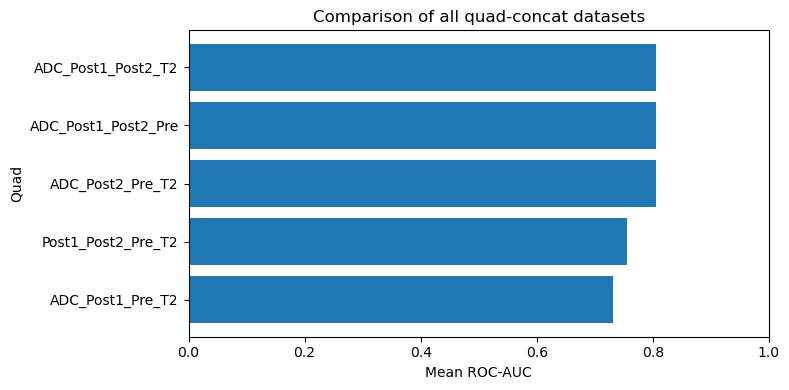

Plot saved:
batch_all_5_quad_runner_artifacts_smote_compare/summary_tables/all_5_quad_mean_auc_barplot.png


In [14]:
# =============================================================================
# CELL 8 — PUBLICATION-STYLE COMPACT TABLE AND OPTIONAL PLOT
# =============================================================================

publication_cols = [
    "Quad_Tag",
    "Dataset_A",
    "Dataset_B",
    "Dataset_C",
    "Dataset_D",
    "Rows_After_Merge",
    "N_Features_Total",
    "Label_Counts",
    "FS_METHOD",
    "FS_N_FEATURES",
    "USE_SMOTE",
    "Model",
    "Mean_AUC",
    "Std_AUC",
    "Pooled_AUC",
    "Mean_PR_AUC",
    "Pooled_PR_AUC",
    "Mean_Bal_Acc",
    "Pooled_Bal_Acc",
    "Mean_F1",
    "Pooled_F1",
    "Avg_Features",
    "N_Unique_Selected_Features",
    "Run_Name",
    "Run_Dir",
    "Final_Status",
    "Result_Error",
]

available_publication_cols = [c for c in publication_cols if c in df_all_5_summary.columns]
df_publication_5_quads = df_all_5_summary[available_publication_cols].copy()

publication_path = SUMMARY_DIR / "publication_all_5_quad_concat_summary.csv"
df_publication_5_quads.to_csv(publication_path, index=False)

print("Publication-style summary saved:")
print(publication_path)

display(df_publication_5_quads)


# Publication-style SMOTE delta table
if "df_quad_smote_vs_no_smote_best" in globals() and len(df_quad_smote_vs_no_smote_best) > 0:
    delta_publication_cols = [
        "Quad_Tag",
        "Dataset_A",
        "Dataset_B",
        "Dataset_C",
        "Dataset_D",
        "Experiment_ID",
        "FS_METHOD",
        "Best_Model_No_SMOTE",
        "Best_Model_SMOTE",
        "Mean_AUC_No_SMOTE",
        "Mean_AUC_SMOTE",
        "Delta_Mean_AUC_SMOTE_minus_No_SMOTE",
        "Pooled_AUC_No_SMOTE",
        "Pooled_AUC_SMOTE",
        "Delta_Pooled_AUC_SMOTE_minus_No_SMOTE",
        "Mean_PR_AUC_No_SMOTE",
        "Mean_PR_AUC_SMOTE",
        "Delta_Mean_PR_AUC_SMOTE_minus_No_SMOTE",
        "Mean_Bal_Acc_No_SMOTE",
        "Mean_Bal_Acc_SMOTE",
        "Delta_Mean_Bal_Acc_SMOTE_minus_No_SMOTE",
        "Avg_Features_No_SMOTE",
        "Avg_Features_SMOTE",
        "Run_Name_No_SMOTE",
        "Run_Name_SMOTE",
    ]
    delta_publication_cols = [
        c for c in delta_publication_cols
        if c in df_quad_smote_vs_no_smote_best.columns
    ]
    df_publication_smote_delta = df_quad_smote_vs_no_smote_best[delta_publication_cols].copy()

    delta_publication_path = SUMMARY_DIR / "publication_all_5_quad_smote_vs_no_smote_summary.csv"
    df_publication_smote_delta.to_csv(delta_publication_path, index=False)

    print("Publication-style SMOTE vs no-SMOTE summary saved:")
    print(delta_publication_path)
    display(df_publication_smote_delta)


# Optional simple plot of Mean_AUC by quad combination.
try:
    import matplotlib.pyplot as plt

    plot_df = df_publication_5_quads.copy()
    plot_df["Mean_AUC_numeric"] = pd.to_numeric(plot_df.get("Mean_AUC"), errors="coerce")
    plot_df = plot_df.dropna(subset=["Mean_AUC_numeric"]).sort_values("Mean_AUC_numeric", ascending=True)

    if len(plot_df) > 0:
        fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(plot_df))))
        ax.barh(plot_df["Quad_Tag"], plot_df["Mean_AUC_numeric"])
        ax.set_xlabel("Mean ROC-AUC")
        ax.set_ylabel("Quad")
        ax.set_title("Comparison of all quad-concat datasets")
        ax.set_xlim(0, 1)
        plt.tight_layout()

        plot_path = SUMMARY_DIR / "all_5_quad_mean_auc_barplot.png"
        fig.savefig(plot_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("Plot saved:")
        print(plot_path)

except Exception as e:
    print("Plot skipped:", e)